Zmienne X_f, X_mi i y zostały zdefiniowane.
Kształt X_f: (100, 10)
Kształt X_mi: (100, 8)
Kształt y: (100,)

Porównanie skuteczności KNN (k=5):

f_classif             → Accuracy: 0.5200
mutual_info_classif   → Accuracy: 0.5500


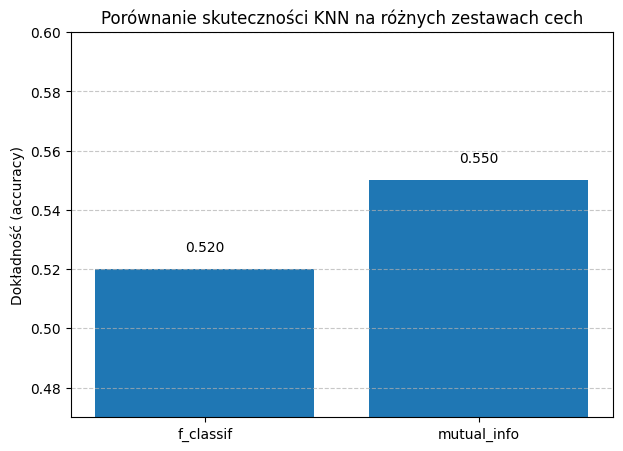

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ustawienie ziarna losowości dla powtarzalności wyników
np.random.seed(42)

# --- Przykładowe dane ---
num_samples = 100
num_features_f = 10
num_features_mi = 8

X_raw = pd.DataFrame(
    np.random.rand(num_samples, 15),
    columns=[f'feature_{i}' for i in range(15)]
)

y = pd.Series(np.random.randint(0, 2, num_samples))  # binarna zmienna celu

# Symulacja wyboru cech
X_f = X_raw.iloc[:, :num_features_f]
X_mi = X_raw.iloc[:, :num_features_mi]

print("Zmienne X_f, X_mi i y zostały zdefiniowane.")
print(f"Kształt X_f: {X_f.shape}")
print(f"Kształt X_mi: {X_mi.shape}")
print(f"Kształt y: {y.shape}")

# --- Parametry KNN ---
k = 5
knn = KNeighborsClassifier(n_neighbors=k)

# Lepszy podział do klasyfikacji binarnej
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- KNN na cechach z f_classif ---
scores_f = cross_val_score(knn, X_f, y, cv=cv, scoring='accuracy')
mean_acc_f = scores_f.mean()

# --- KNN na cechach z mutual_info_classif ---
scores_mi = cross_val_score(knn, X_mi, y, cv=cv, scoring='accuracy')
mean_acc_mi = scores_mi.mean()

# --- Wyniki ---
print("\nPorównanie skuteczności KNN (k=5):\n")
print(f"f_classif             → Accuracy: {mean_acc_f:.4f}")
print(f"mutual_info_classif   → Accuracy: {mean_acc_mi:.4f}")

# --- Wykres porównawczy ---
methods = ['f_classif', 'mutual_info']
accuracies = [mean_acc_f, mean_acc_mi]

plt.figure(figsize=(7, 5))
bars = plt.bar(methods, accuracies)

plt.ylabel("Dokładność (accuracy)")
plt.title("Porównanie skuteczności KNN na różnych zestawach cech")

# Dynamiczna skala osi Y zamiast sztywnego 0.9-1.0
y_min = max(0, min(accuracies) - 0.05)
y_max = min(1.0, max(accuracies) + 0.05)
plt.ylim(y_min, y_max)

plt.grid(axis='y', linestyle='--', alpha=0.7)

# Dodanie wartości nad słupkami
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{acc:.3f}",
        ha='center',
        va='bottom'
    )

plt.show()